# Import libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score, mean_absolute_percentage_error
import joblib

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('ggplot')

# Load Dataset

In [2]:
df = pd.read_csv('ai-python/FpsTest/fps_dataset.csv')

In [3]:
df.head()

,CPU,CPU Cores,CPU Threads,CPU TDP (W),GPU,GPU Series,GPU VRAM (GB),GPU Bandwidth (GB/s),GPU TDP (W),Total System TDP (W),Bottleneck Score,RAM (GB),Resolution,Graphics Settings,Min FPS,Avg FPS,Max FPS
0,Intel i7-12700F,12,20,65,RTX 2070,RTX 2000,8,448,300,365,3.50,8,3840x2160,High,28,35,43
1,Intel i5-12600K,10,16,125,RX 6800,RX 6000,16,512,150,275,5.00,8,1920x1080,Low,72,93,102
2,Ryzen 9 5900X,12,24,105,RTX 3080,RTX 3000,10,760,200,305,3.96,8,2560x1440,High,51,71,84
3,Intel i7-13700K,16,24,125,RTX 3070,RTX 3000,8,448,200,325,3.33,8,2560x1440,Low,60,80,93
4,Intel i5-12400F,6,12,65,RX 6900 XT,RX 6000,16,512,200,265,7.50,16,3840x2160,Low,48,65,79


# Check Data is clean and good

Check missing values

In [4]:
print("Missing Values...")
print(df.isnull().sum())

Missing Values...
CPU                     0
CPU Cores               0
CPU Threads             0
CPU TDP (W)             0
GPU                     0
GPU Series              0
GPU VRAM (GB)           0
GPU Bandwidth (GB/s)    0
GPU TDP (W)             0
Total System TDP (W)    0
Bottleneck Score        0
RAM (GB)                0
Resolution              0
Graphics Settings       0
Min FPS                 0
Avg FPS                 0
Max FPS                 0
dtype: int64


Finding for Hidden Whitespace

In [5]:
# Create a copy of the dataframe to clean
df_clean = df.copy()

# Strip hidden spaces from the beginning and end of all text columns
for col in df_clean.select_dtypes(include=['object']).columns:
    df_clean[col] = df_clean[col].str.strip()

print("All hidden trailing and leading spaces removed from text columns!")

All hidden trailing and leading spaces removed from text columns!


Spotting Symbols in Text Columns

In [6]:

print("Unique CPUs in dataset:")
print(df_clean['CPU'].unique())

print("\nUnique GPUs in dataset:")
print(df_clean['GPU'].unique())

Unique CPUs in dataset:
['Intel i7-12700F' 'Intel i5-12600K' 'Ryzen 9 5900X' 'Intel i7-13700K'
 'Intel i5-12400F' 'Intel i9-13900K' 'Ryzen 3 4100' 'Intel i9-12900K'
 'Ryzen 5 7600X' 'Intel i9-14900K' 'Ryzen 9 7950X3D' 'Ryzen 7 7800X3D'
 'Intel i3-12100F' 'Ryzen 9 7950X' 'Ryzen 5 5600X' 'Ryzen 7 5800X']

Unique GPUs in dataset:
['RTX 2070' 'RX 6800' 'RTX 3080' 'RTX 3070' 'RX 6900 XT' 'GTX 1060'
 'RTX 3080 Ti' 'RTX 2080 Ti' 'RTX 3090' 'GTX 1070' 'RX 6600' 'RTX 4080'
 'RX 7800 XT' 'RTX 4070 Ti' 'GTX 1650 Super' 'RTX 4070' 'RTX 2080'
 'RTX 3060 Ti' 'GTX 1080 Ti' 'RTX 3060' 'RTX 4060' 'Intel Arc A770'
 'RTX 4070 Super' 'RTX 4090' 'RTX 4080 Super' 'Intel Arc A750'
 'RX 7900 XTX' 'RX 7600' 'RX 7700 XT' 'RX 6700 XT' 'GTX 1660' 'RX 6800 XT'
 'RTX 2060' 'RX 6600 XT']


erasing Symbols from Numbers

In [7]:
if 'cpuMark' in df_clean.columns:
    # Use Regular Expressions (regex) to replace anything that is NOT a digit (\d) or decimal (\.)
    df_clean['cpuMark'] = df_clean['cpuMark'].astype(str).str.replace(r'[^\d.]', '', regex=True)
    
    # Convert it back to a clean number type
    df_clean['cpuMark'] = pd.to_numeric(df_clean['cpuMark'])
    print("Symbols removed from cpuMark!")

Remove Duplicates data's

In [8]:
# Count duplicates
duplicates = df_clean.duplicated().sum()
print(f"Found {duplicates} duplicate rows.")

# Drop them permanently
if duplicates > 0:
    df_clean = df_clean.drop_duplicates()
    print("Duplicates removed. Dataset is clean.")

Found 0 duplicate rows.


# Data Preprocessing

In [9]:
print(f"Original shape: {df.shape}")

Original shape: (1000, 17)


Separate target FPS from hardware features.....

In [10]:
y = df['Avg FPS']
X_raw  = df.drop(columns=['Avg FPS'])

Converting text to Numbers.....

In [11]:
X = pd.get_dummies(X_raw)
print(f"Encoded shape:{X.shape}")

Encoded shape:(1000, 75)


# Train and Test 

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=42)
print(f"Training on {len(X_train)} setups, Testing on {len(X_test)} setups.")

Training on 800 setups, Testing on 200 setups.


# Train Random Forest Model

Initial model with 100 trees....

In [13]:
model = RandomForestRegressor(n_estimators=100, random_state=42)

Train the model....

In [14]:
model.fit(X_train, y_train)
print("Model train Complete!")

Model train Complete!


- Algorithm Comparison Results -
Linear Regression average error: 1.69 FPS
Single Decision Tree average error: 2.61 FPS
Random Forest (Project Aura) average error: 1.70 FPS


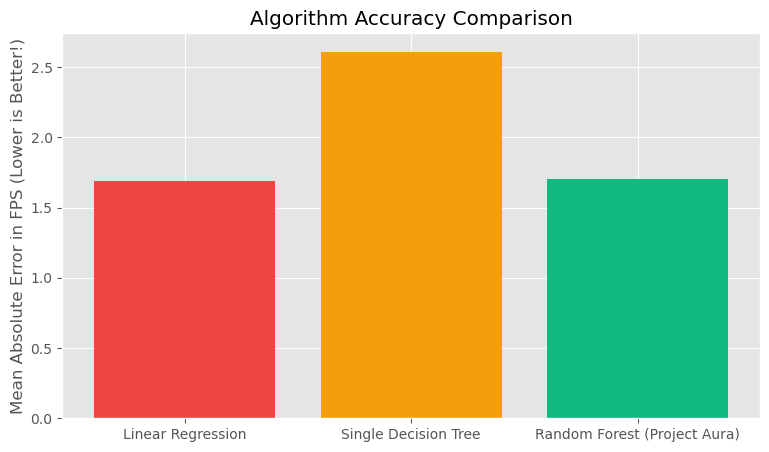

In [15]:
# 1. Set up the three competitors
algorithms = {
    "Linear Regression": LinearRegression(),
    "Single Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest (Project Aura)": RandomForestRegressor(n_estimators=100, random_state=42)
}

errors = {}

# 2. Train and test each algorithm in a loop
print("- Algorithm Comparison Results -")
for name, model in algorithms.items():
    # Train the model
    model.fit(X_train, y_train)
    
    # Test the model
    predictions = model.predict(X_test)
    
    # Calculate how wrong the model was on average (Mean Absolute Error)
    mae = mean_absolute_error(y_test, predictions)
    errors[name] = mae
    
    print(f"{name} average error: {mae:.2f} FPS")

# 3. Graph the Results to prove Random Forest is best
plt.figure(figsize=(9, 5))
plt.bar(errors.keys(), errors.values(), color=['#ef4444', '#f59e0b', '#10b981']) #Chart colors
plt.ylabel('Mean Absolute Error in FPS (Lower is Better!)')
plt.title('Algorithm Accuracy Comparison')
plt.show()

# Chart Generation

Use 20% of Data for Testing...

In [16]:
predictions =  model.predict(X_test)

Calculate the MAE ( Mean )...

In [17]:
mae  = mean_absolute_error(y_test, predictions)
print(f"Mean Absolute Error: {mae:.2f} FPS")

Mean Absolute Error: 1.70 FPS


Actual vs Predicted FPS

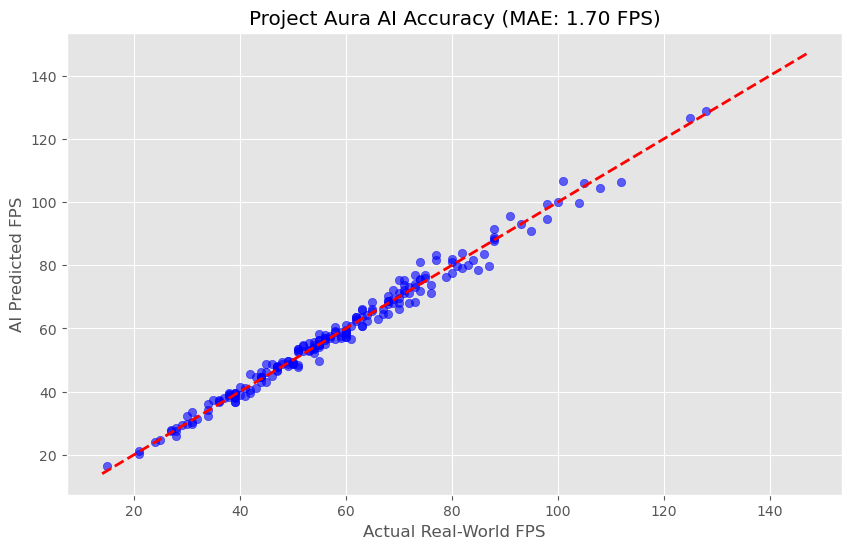

In [18]:
plt.figure(figsize=(10, 6))  #Plot
plt.scatter(y_test, predictions, alpha=0.6, color='blue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # The perfect accuracy line
plt.xlabel('Actual Real-World FPS')
plt.ylabel('AI Predicted FPS')
plt.title(f'Project Aura AI Accuracy (MAE: {mae:.2f} FPS)')
plt.show()

# Feature Important Chart

In [19]:
importances = model.feature_importances_  #What hardware spec matters


Get the top 10 important features

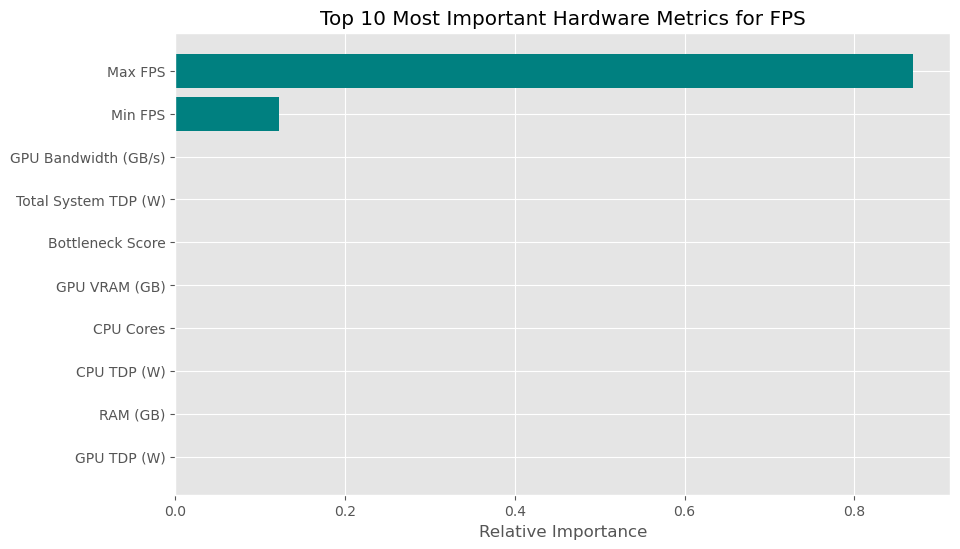

In [20]:
indices = np.argsort(importances)[-10:]
plt.figure(figsize=(10, 6))
plt.title('Top 10 Most Important Hardware Metrics for FPS')
plt.barh(range(len(indices)), importances[indices], color='teal', align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

AI actually learned the rules of PC hardware. It will likely show that "GPU CUDA Score" or "CPU Threads" have the biggest impact on framerates!

# Export the trained Brain

In [21]:
# Save the model
joblib.dump(model, 'project_aura.joblib')
joblib.dump(list(X.columns), 'ai_columns.joblib')
print("Model and Columns successfully saved! Ready for web integration.")

Model and Columns successfully saved! Ready for web integration.


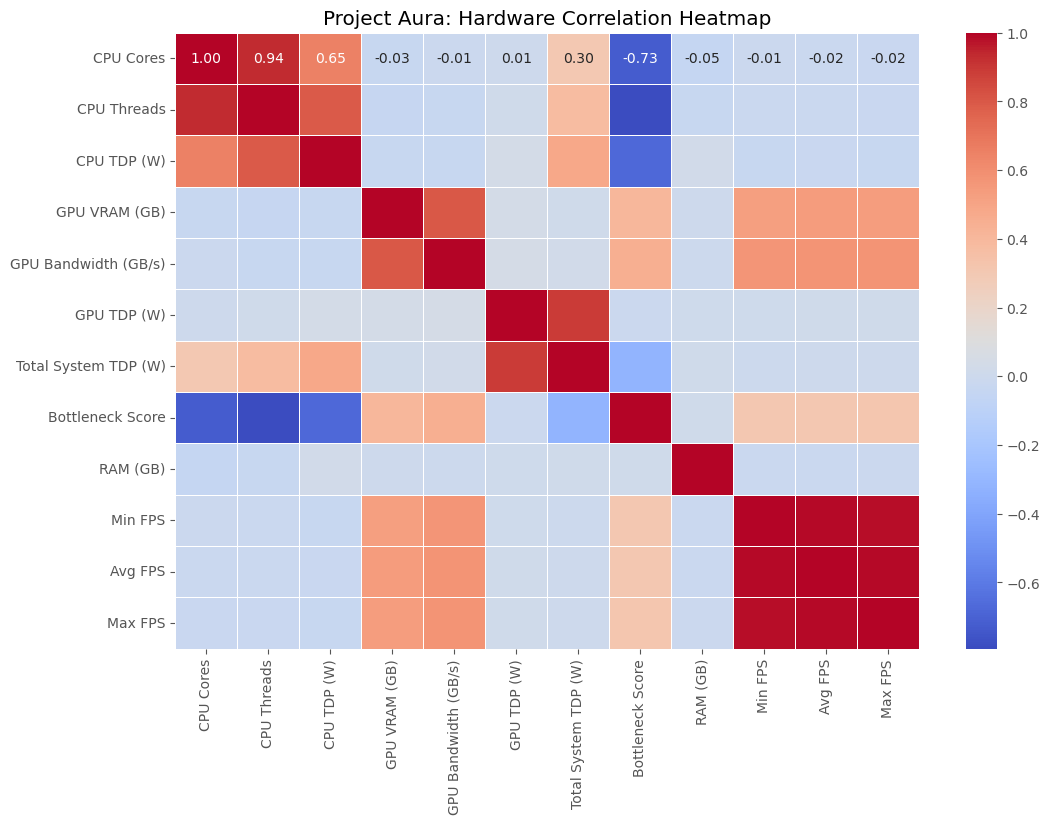

In [22]:


# Create a beautiful heatmap to see what correlates most with FPS
plt.figure(figsize=(12, 8))

# We use numeric_only=True because math only works on numbers, not text!
correlation_matrix = df_clean.corr(numeric_only=True)

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Project Aura: Hardware Correlation Heatmap")
plt.show()

# Get Accuracy 

Calculate R2 Score

In [23]:
r2 = r2_score(y_test, predictions)

Calculate MAPE ( Mean Absolute precentage Err )

In [24]:
mape  = mean_absolute_percentage_error(y_test, predictions)

Calculate MAPE into Readable way

In [25]:
accuracy_percentage = 100 - (mape*100)

Print Report 

In [28]:
print("Project Aura Final Accuracy Report")
print("----------------------------------")
print(f"1.Mean Absolute Err (MAE): {mae:.2f} FPS")
print(f"2.Average Percentage Error:{(mape*100):.2f}%")
print(f"3.Overall Model Accuracy:  {accuracy_percentage:.2f}%")
print(f"4.R-squared Score (R2):    {r2:4f}")   #How much better is this AI than just guessing the average every timeS

if accuracy_percentage > 90:
    print("\nCONCLUSION: The model is highly accurate and ready for production.")

else:
    print("\nCONCLUSION: The model needs more training data.")



Project Aura Final Accuracy Report
----------------------------------
1.Mean Absolute Err (MAE): 1.70 FPS
2.Average Percentage Error:2.94%
3.Overall Model Accuracy:  97.06%
4.R-squared Score (R2):    0.987377

CONCLUSION: The model is highly accurate and ready for production.
